In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("datasets/train.csv")
M, N = df.shape
df.head(5)

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


### Анализ количества и природы пропусков

In [3]:
# сначала найдём все потенциально невалидные даанные
borders = {"sleep_duration": [0.0, 24.0], "heart_rate": [0.0, 220.0], "bmi": [0.0, 100],
           "calorie_expenditure": [0.0, np.inf], "step_count": [0.0, np.inf], 
           "exercise_duration": [0.0, 1440.0], "water_intake": [0.0, np.inf],
           "diet_type": ("veg", "non-veg", "balanced"), "stress_level": ("low", "high", "medium"),
           "sleep_quality": ('average', 'poor', 'good'), "physical_activity_level": ('sedentary', 'moderate', 'active'),
           "smoking_alcohol": ('yes', 'occasional', 'no'), "gender": ('female', 'other', 'male')}

for col_name in df.columns:
    if col_name not in borders:
        continue
    else:
        try:
            if type(borders[col_name]) is tuple:
                mask = ~(df[col_name].isin(borders[col_name]) | df[col_name].isna())
            elif type(borders[col_name]) is list:
                mask = ~(((df[col_name] >= borders[col_name][0]) & (df[col_name] <= borders[col_name][1])) | df[col_name].isna())
            else:
                raise AttributeError("Нестандартный тип данных из словаря borders")
        except AttributeError as ae:
            print(f"Словарь borders повреждён: {ae}")
        
            

### Вывод
Данные лежат в валидных интервалах

In [4]:
df.isnull().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

In [5]:
missing_per_row = df.isnull().sum(axis=1)
missing_counts = [[num, np.round(num/M, 2)] for num in missing_per_row.value_counts().sort_index()]
print("Количество строк с определенным числом пропусков (кол-во, процент от всего df):")
print(*missing_counts, sep="\n")

Количество строк с определенным числом пропусков (кол-во, процент от всего df):
[349623, np.float64(0.51)]
[248134, np.float64(0.36)]
[77311, np.float64(0.11)]
[13445, np.float64(0.02)]
[1479, np.float64(0.0)]
[87, np.float64(0.0)]
[9, np.float64(0.0)]


In [6]:
# так как общий процент сэмплов с 3+ пропусками <= 0.2, то откинем их
print((df.isnull().sum(axis=1) >= 3).sum())
df = df[~(df.isnull().sum(axis=1) >= 3)]

15020


Дальше надо решить проблему обработки категориальных признаков. Воспользуемся One Hot Encoding

In [7]:
# Заменяем NaN на медианные значения
from sklearn.preprocessing import OneHotEncoder

columns_categor = ["diet_type", "stress_level", "sleep_quality", "physical_activity_level", "smoking_alcohol", "gender"]

df_Y = df[["id", "health_condition"]].copy()
df.drop(columns=["id", "health_condition"], inplace=True)

df_numerical = df.drop(columns=columns_categor)
df_numerical = df_numerical.fillna(df_numerical.median())

df_categorical = df[columns_categor].fillna("Missing")
encoder = OneHotEncoder(sparse_output=False)
df_categorical_encoded = encoder.fit_transform(df_categorical)

df_categorical = pd.DataFrame(
    df_categorical_encoded,
    columns=encoder.get_feature_names_out(columns_categor),
    index=df_categorical.index 
)

df = pd.concat([df_Y, df_numerical, df_categorical], axis=1)

print(df.isna().sum())

id                                   0
health_condition                     0
sleep_duration                       0
heart_rate                           0
bmi                                  0
calorie_expenditure                  0
step_count                           0
exercise_duration                    0
water_intake                         0
diet_type_Missing                    0
diet_type_balanced                   0
diet_type_non-veg                    0
diet_type_veg                        0
stress_level_Missing                 0
stress_level_high                    0
stress_level_low                     0
stress_level_medium                  0
sleep_quality_Missing                0
sleep_quality_average                0
sleep_quality_good                   0
sleep_quality_poor                   0
physical_activity_level_Missing      0
physical_activity_level_active       0
physical_activity_level_moderate     0
physical_activity_level_sedentary    0
smoking_alcohol_Missing  

#### Проверка распределения

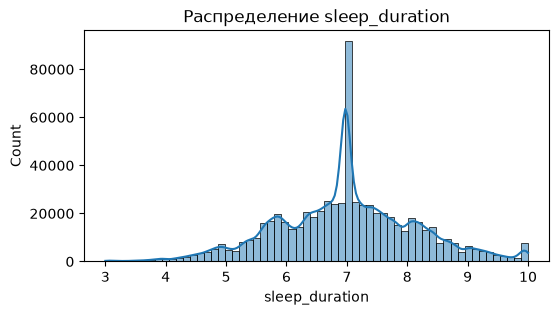

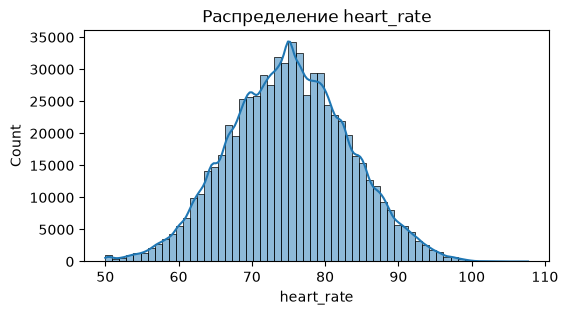

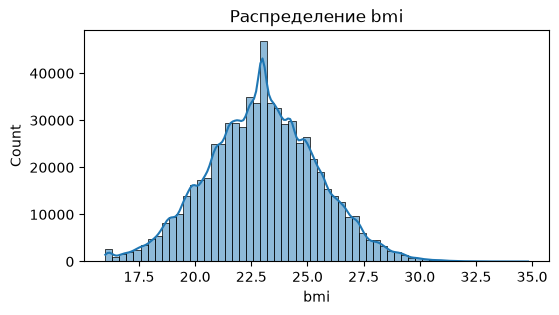

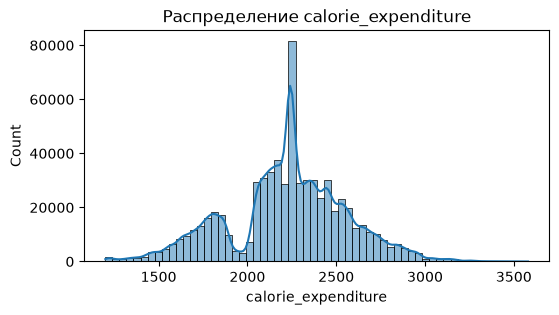

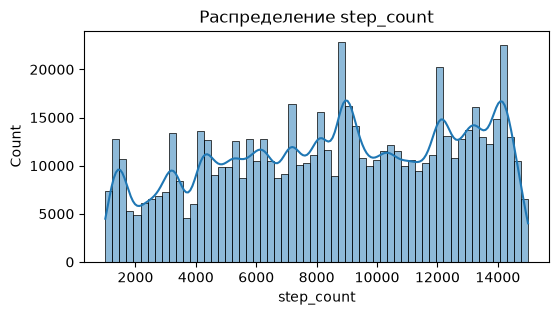

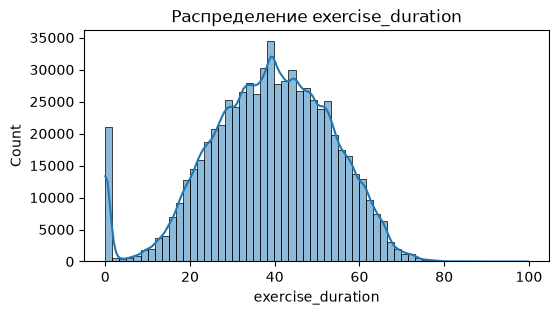

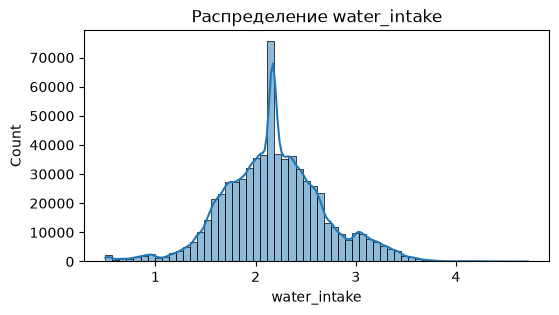

In [8]:
import seaborn as sns


columns = ["sleep_duration", "heart_rate", "bmi", "calorie_expenditure", 
           "step_count", "exercise_duration", "water_intake"]

for column in columns:
    plt.figure(figsize=(6, 3))
    sns.histplot(df[column], kde=True, bins=60)
    plt.title(f'Распределение {column}')
    plt.show()

### Проверяем нормальность распределения по всем величинам
Критерий Хи-квадрат К. Пирсона для сложной гипотезы

In [16]:
from scipy import stats

for column in columns:
    expected_value = df[column].sum() / M 
    dispersion = np.sum((df[column] - expected_value)**2) / (M - 1)
    std_dev = np.sqrt(dispersion)

    b = 10
    counts, bin_edges = np.histogram(df[column], bins=b)
    
    if any(i < 5 for i in counts):
        new_counts = []
        new_bin_edges = [bin_edges[0]]
        
        i = 0
        n_bins = len(counts)
        
        while i < n_bins:
            local_count = counts[i]
            start_idx = i
 
            while local_count <= 5 and i < n_bins - 1:
                i += 1
                local_count += counts[i]
            
            new_counts.append(local_count)
            new_bin_edges.append(bin_edges[i + 1])
            i += 1

        if len(new_counts) > 1 and new_counts[-1] <= 5:
            last_count = new_counts.pop()
            new_counts[-1] += last_count
            new_bin_edges.pop(-2)
            
        counts = np.array(new_counts)
        bin_edges = np.array(new_bin_edges)

    # 1. Вычисляем теоретические вероятности попадания в каждый бин
    # Для этого расширяем крайние границы до бесконечности, чтобы учесть хвосты распределения
    theoretical_probs = []
    
    for k in range(len(counts)):
        # Левая граница интервала
        low = -np.inf if k == 0 else bin_edges[k]
        # Правая граница интервала
        high = np.inf if k == len(counts) - 1 else bin_edges[k + 1]
        
        # Разность функций распределения (CDF) дает вероятность попадания в интервал
        p = stats.norm.cdf(high, loc=expected_value, scale=std_dev) - stats.norm.cdf(low, loc=expected_value, scale=std_dev)
        theoretical_probs.append(p)
        
    theoretical_probs = np.array(theoretical_probs)
    
    # 2. Переводим вероятности в ожидаемые (теоретические) частоты
    expected_counts = theoretical_probs * M
    
    # 3. Расчет статистики Хи-квадрат Пирсона
    # Формула: sum((O_i - E_i)^2 / E_i)
    chi2_stat = np.sum((counts - expected_counts) ** 2 / expected_counts)
    
    # 4. Расчет степеней свободы для СЛОЖНОЙ гипотезы
    # df = K (кол-во бинов) - 1 (обязательная связь) - c (кол-во оцененных параметров распределения)
    # Для нормального распределения мы оценили 2 параметра: среднее и дисперсию (c = 2)
    c = 2 
    degrees_of_freedom = len(counts) - 1 - c
    
    if degrees_of_freedom <= 0:
        print(f"Колонка {column}: Недостаточно бинов ({len(counts)}) после объединения для проверки гипотезы.")
        continue
        
    # 5. Находим p-value (вероятность получить такое или еще более экстремальное значение статистики)
    p_value = 1 - stats.chi2.cdf(chi2_stat, df=degrees_of_freedom)
    
    # 6. Вывод результатов
    alpha = 0.95 # уровень значимости
    print(f"--- Результаты проверки для колонки: {column} ---")
    print(f"Количество бинов после объединения: {len(counts)}")
    print(f"Статистика Хи-квадрат: {chi2_stat:.4f}")
    print(f"Степеней свободы: {degrees_of_freedom}")
    print(f"p-value: {p_value:.4f}")
    
    if p_value < alpha:
        print("Результат: Отклоняем нулевую гипотезу (H0). Данные НЕ подчиняются нормальному закону.")
    else:
        print("Результат: Не удалось отклонить нулевую гипотезу (H0). Данные согласуются с нормальным законом.")
    print()

--- Результаты проверки для колонки: sleep_duration ---
Количество бинов после объединения: 10
Статистика Хи-квадрат: 36970.9765
Степеней свободы: 7
p-value: 0.0000
Результат: Отклоняем нулевую гипотезу (H0). Данные НЕ подчиняются нормальному закону.

--- Результаты проверки для колонки: heart_rate ---
Количество бинов после объединения: 10
Статистика Хи-квадрат: 28084.8443
Степеней свободы: 7
p-value: 0.0000
Результат: Отклоняем нулевую гипотезу (H0). Данные НЕ подчиняются нормальному закону.

--- Результаты проверки для колонки: bmi ---
Количество бинов после объединения: 10
Статистика Хи-квадрат: 24723.5414
Степеней свободы: 7
p-value: 0.0000
Результат: Отклоняем нулевую гипотезу (H0). Данные НЕ подчиняются нормальному закону.

--- Результаты проверки для колонки: calorie_expenditure ---
Количество бинов после объединения: 10
Статистика Хи-квадрат: 45979.7556
Степеней свободы: 7
p-value: 0.0000
Результат: Отклоняем нулевую гипотезу (H0). Данные НЕ подчиняются нормальному закону.

--